# Space-Time DeepSearch: LandTrendr Change Detection

End-to-end example using the `SpaceTimeDeepSearch` core module:

1. Fetch multi-year Sentinel-2 NDVI via the core entry point  
2. Annual-composite the time series  
3. Run LandTrendr segmentation  
4. Extract and visualise Year of Detection, Magnitude, and Duration  
5. Inspect a single pixel trajectory


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from space_time_deepsearch.core import SpaceTimeDeepSearch
from space_time_deepsearch.temporal._landtrendr_core import landtrendr_pixel
import math
def get_500m_bbox(lat, lon):
    """
    Returns a 500m bounding box (approx. 250m offset from center).
    Format: (min_lon, min_lat, max_lon, max_lat)
    """
    # Earth's radius in meters
    R = 6378137
    
    # Coordinate offsets in radians
    d_lat = 250 / R
    d_lon = 250 / (R * math.cos(math.pi * lat / 180))
    
    # Convert offsets to degrees
    offset_lat = d_lat * 180 / math.pi
    offset_lon = d_lon * 180 / math.pi
    
    return (
        round(lon - offset_lon, 5), # min_lon
        round(lat - offset_lat, 5), # min_lat
        round(lon + offset_lon, 5), # max_lon
        round(lat + offset_lat, 5)  # max_lat
    )

# Example for your coordinates: [2.69271, -74.06598]
bbox = get_500m_bbox(2.69271, -74.06598)
print(bbox)

(-74.06823, 2.69046, -74.06373, 2.69496)


## 1. Area of Interest

Define a bounding box or use a city name. The core module handles geocoding automatically.


In [2]:
# Option A: bounding box (west, south, east, north) in WGS84
BBOX = (4.85, 52.32, 4.95, 52.40)

stds = SpaceTimeDeepSearch(bbox=get_500m_bbox(-6.843131249979253,  -56.61152178469765))
stds2 = SpaceTimeDeepSearch(bbox=get_500m_bbox(52.52,  5.65))
# Option B: city name (uncomment to use instead)
# stds = SpaceTimeDeepSearch(city="Amsterdam, Netherlands")


## 2. Fetch Sentinel-2 NDVI

Retrieve a multi-year time series. We use quarterly composites here so that
each year contributes ~4 cloud-free observations before annual collapsing.


In [3]:
s2 = stds2.get_sentinel2(
    start_date="2013-01-01",
    end_date="2026-01-01",
    cloud_cover_max=20,
    min_coverage=70,
    mask_clouds=True,
    composite_period="2M",   # quarterly composites
    add_ndvi=True,
)

# Select NDVI band → (time, y, x)
ndvi = s2.sel(band="NDVI", drop=True)
print(f"NDVI datacube: {ndvi.dims}  shape={ndvi.shape}")
ndvi


Found 1145 candidate Sentinel-2 scenes
Using EPSG:32631 for projection
Filtering scenes: Cloud < 20%, Coverage >= 70%...
Computing local cloud stats...
[########################################] | 100% Completed | 9.43 ss
Retained 396 scenes after local filtering (max 20%)
Compositing data over 2M using median...


c:\Users\darey\AppData\Local\pypoetry\Cache\virtualenvs\ex7-Kjj2zdUm-py3.11\Lib\site-packages\xarray\groupers.py:543: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


[########################################] | 100% Completed | 54.26 s
NDVI datacube: ('time', 'y', 'x')  shape=(63, 53, 53)


<xarray.DataArray 'stackstac-22797713b55a6663525e73b9acf464f7' (time: 63,
                                                                y: 53, x: 53)> Size: 1MB
array([[[0.11387551, 0.11908439, 0.12007529, ..., 0.50595018,
         0.51436842, 0.51883871],
        [0.10188904, 0.10528732, 0.11287706, ..., 0.51364971,
         0.5219094 , 0.50903154],
        [0.10392871, 0.10789928, 0.11513752, ..., 0.51450887,
         0.51260456, 0.50765328],
        ...,
        [0.75654181, 0.75644684, 0.75366648, ..., 0.88099307,
         0.88717854, 0.89957242],
        [0.75763343, 0.74085781, 0.73948552, ..., 0.89687877,
         0.9032816 , 0.90329378],
        [0.74007003, 0.74741187, 0.75259623, ..., 0.89836618,
         0.90753093, 0.90699765]],

       [[0.81767153, 0.8100014 , 0.79250692, ..., 0.12736233,
         0.13442464, 0.13205058],
        [0.80749654, 0.79865881, 0.79245916, ..., 0.12665065,
         0.12294461, 0.12131672],
        [0.82062769, 0.8134233 , 0.81875893, ..., 0.12325355,
         0.11913258, 0.12200877],
...
        [0.21216766, 0.23736941, 0.25205625, ..., 0.56577736,
         0.49225684, 0.51113185],
        [0.23662792, 0.2442834 , 0.25271878, ..., 0.55318717,
         0.49313414, 0.46678179],
        [0.28085273, 0.30773054, 0.35938886, ..., 0.56407392,
         0.55733919, 0.55953762]],

       [[0.08343711, 0.0958231 , 0.09680032, ..., 0.06401637,
         0.07527504, 0.07888631],
        [0.0778292 , 0.07834101, 0.10190824, ..., 0.0647986 ,
         0.06128376, 0.07178146],
        [0.08354219, 0.08409659, 0.0951586 , ..., 0.06472303,
         0.05694895, 0.06348282],
        ...,
        [0.05547571, 0.05697309, 0.06390575, ..., 0.28079242,
         0.26104784, 0.30851944],
        [0.06410256, 0.07113939, 0.07111756, ..., 0.30320316,
         0.26716049, 0.27989006],
        [0.07722132, 0.17787913, 0.21676151, ..., 0.31293706,
         0.27815468, 0.30289066]]], shape=(63, 53, 53))
Coordinates:
  * time     (time) datetime64[ns] 504B 2015-08-31 2015-10-31 ... 2025-12-31
  * y        (y) float64 424B 5.822e+06 5.822e+06 ... 5.822e+06 5.822e+06
  * x        (x) float64 424B 6.795e+05 6.795e+05 6.796e+05 ... 6.8e+05 6.8e+05
    epsg     int64 8B 32631
Attributes: (12/13)
    spec:             RasterSpec(epsg=32631, bounds=(679530, 5821910, 680060,...
    crs:              epsg:32631
    transform:        | 10.00, 0.00, 679530.00|\n| 0.00,-10.00, 5822440.00|\n...
    resolution:       10
    source:           Microsoft Planetary Computer
    collection:       sentinel-2-l2a
    ...               ...
    end_date:         2026-01-01
    cloud_cover_max:  20
    min_coverage:     70
    mask_clouds:      True
    ndvi_added:       True
    ndbi_added:       False

In [4]:
# Select just the NDVI band → dims become (time, y, x)
ndvi = s2.sel(band="NDVI", drop=True)
print(f"\nNDVI datacube: shape={ndvi.shape}  time steps={len(ndvi.time)}")


NDVI datacube: shape=(63, 53, 53)  time steps=63


In [5]:
# Pick a pixel (centre of the image, or any y/x coordinate)
cy = float(ndvi.y.values[len(ndvi.y) // 2])
cx = float(ndvi.x.values[len(ndvi.x) // 2])
pixel = ndvi.sel(y=cy, x=cx, method="nearest")

In [6]:
pixel=pixel.sel(time=slice("2023-01-01", "2026-06-01"))

In [8]:
# Extract numpy arrays — handle datetime64 properly
if np.issubdtype(pixel.time.dtype, np.datetime64):
    years = pixel.time.dt.year.values.astype(np.int32)
else:
    years = pixel.time.values.astype(np.int32)

years = pixel.time.values.astype(np.int32)
values = pixel.values.astype(np.float64)

print(f"Years: {years}")
print(f"Values: {np.round(values, 3)}")

# Run LandTrendr on this single pixel
fitted, is_vertex, rmse = landtrendr_pixel(years, values)


Years: [-1079508992  1601896448   -11665408   812646400  -800915456  1880489984
  2124021760   510459904 -1103101952  -278790144 -1892352000   789053440
 -1405288448  1276116992  -337444864   486866944 -1126694912  1554710528]
Values: [0.15  0.223 0.062 0.083 0.383 0.64  0.37  0.118 0.057 0.504 0.678 0.078
 0.087 0.07  0.106 0.489 0.085 0.531]


C:\Users\darey\OneDrive - University of Twente\Documents\Repositories\Space-Time-DeepSearch\Space-Time-DeepSearch\src\space_time_deepsearch\temporal\_landtrendr_core.py:110: RuntimeWarning: overflow encountered in scalar subtract
  dy_after = years[next_idx] - years[curr_idx]
C:\Users\darey\OneDrive - University of Twente\Documents\Repositories\Space-Time-DeepSearch\Space-Time-DeepSearch\src\space_time_deepsearch\temporal\_landtrendr_core.py:109: RuntimeWarning: overflow encountered in scalar subtract
  dy_before = years[curr_idx] - years[prev_idx]
C:\Users\darey\OneDrive - University of Twente\Documents\Repositories\Space-Time-DeepSearch\Space-Time-DeepSearch\src\space_time_deepsearch\temporal\_landtrendr_core.py:201: RuntimeWarning: overflow encountered in scalar subtract
  duration = years[end_idx] - years[start_idx]


Years        : [-1079508992  1601896448   -11665408   812646400  -800915456  1880489984
  2124021760   510459904 -1103101952  -278790144 -1892352000   789053440
 -1405288448  1276116992  -337444864   486866944 -1126694912  1554710528]
Source NDVI  : [0.15  0.223 0.062 0.083 0.383 0.64  0.37  0.118 0.057 0.504 0.678 0.078
 0.087 0.07  0.106 0.489 0.085 0.531]
Fitted NDVI  : [0.057 0.531 0.069 0.092 0.06  0.531 0.531 0.075 0.057 0.066 0.057 0.078
 0.057 0.366 0.065 0.075 0.057 0.531]
Vertex years : [-1079508992  1554710528]
Segments     : 1
RMSE         : 0.1948


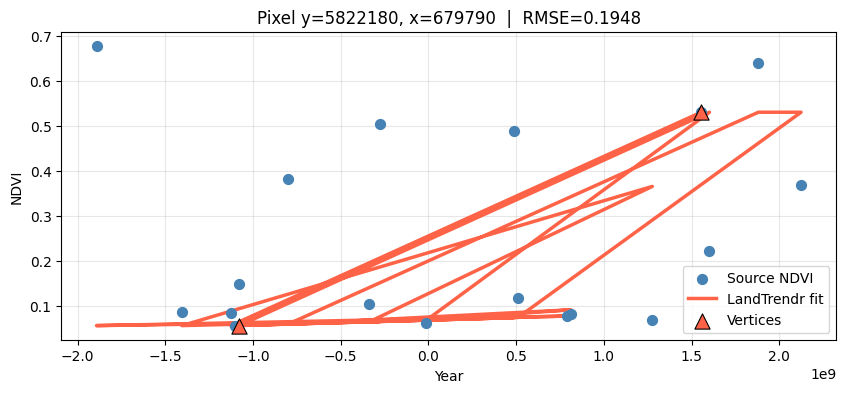

In [9]:
# Run LandTrendr on this single pixel
fitted, is_vertex, rmse = landtrendr_pixel(years, values,
    max_segments=20, 
    spike_threshold=0.9,
                     vertex_count_overshoot=3, 
                     prevent_one_year_recovery=True,
                     recovery_threshold=0.25, 
                     pval_threshold=0.05,
                     best_model_proportion=0.75, 
                     min_observations_needed=6)

# Print results
print(f"Years        : {years}")
print(f"Source NDVI  : {np.round(values, 3)}")
print(f"Fitted NDVI  : {np.round(fitted, 3)}")
print(f"Vertex years : {years[is_vertex]}")
print(f"Segments     : {np.sum(is_vertex) - 1}")
print(f"RMSE         : {rmse:.4f}")

# --- Plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.scatter(years, values, color="steelblue", s=50, zorder=3, label="Source NDVI")
plt.plot(years, fitted, color="tomato", lw=2.5, zorder=2, label="LandTrendr fit")
plt.scatter(years[is_vertex], fitted[is_vertex], marker="^", color="tomato",
            s=120, edgecolors="black", lw=0.8, zorder=4, label="Vertices")
plt.xlabel("Year")
plt.ylabel("NDVI")
plt.legend()
plt.grid(alpha=0.3)
plt.title(f"Pixel y={cy:.0f}, x={cx:.0f}  |  RMSE={rmse:.4f}")
plt.show()

## 3. Run LandTrendr

`run_landtrendr` on the core module automatically composites the quarterly data
to annual medians before segmentation.


In [48]:
from space_time_deepsearch.temporal import LandTrendrParams

lt_result = stds.run_landtrendr(
    ndvi,
    composite_to_annual=False,
    params=LandTrendrParams(
        max_segments=30,
        spike_threshold=1.0,
        vertex_count_overshoot=30,
        prevent_one_year_recovery=False,
        recovery_threshold=1.0,
        pval_threshold=1.0,
        best_model_proportion=1.0,
        min_observations_needed=6,
    ),
)

lt_result


<xarray.Dataset> Size: 508kB
Dimensions:        (x: 51, y: 51, time: 11)
Coordinates:
  * x              (x) float64 408B 5.427e+05 5.427e+05 ... 5.432e+05 5.432e+05
  * y              (y) float64 408B 9.244e+06 9.244e+06 ... 9.243e+06 9.243e+06
  * time           (time) datetime64[ns] 88B 2015-12-31 ... 2025-12-31
    epsg           int64 8B 32721
Data variables:
    source_values  (time, y, x) float64 229kB 0.3971 0.2923 ... 0.1842 0.1713
    fitted_values  (time, y, x) float64 229kB 0.3971 0.2923 ... 0.1842 0.1713
    is_vertex      (time, y, x) bool 29kB True True True True ... True True True
    rmse           (y, x) float64 21kB 0.02222 0.07853 ... 0.01211 0.009093

## 4. Extract Change Maps

Equivalent to GEE's LandTrendr Change Mapper.  
`delta_filter="loss"` isolates vegetation loss events (negative NDVI change).


In [49]:
change = stds.extract_change_map(
    lt_result,
    change_type="greatest",   # largest magnitude segment
    delta_filter="loss",      # negative NDVI change only
)

# Available variables: yod, mag, dur, preval, rate, dsnr
change


<xarray.Dataset> Size: 126kB
Dimensions:  (x: 51, y: 51)
Coordinates:
  * x        (x) float64 408B 5.427e+05 5.427e+05 ... 5.432e+05 5.432e+05
  * y        (y) float64 408B 9.244e+06 9.244e+06 ... 9.243e+06 9.243e+06
    epsg     int64 8B 32721
Data variables:
    yod      (y, x) float64 21kB 2.021e+03 2.019e+03 ... 2.02e+03 2.02e+03
    mag      (y, x) float64 21kB -0.4261 -0.3778 -0.3576 ... -0.1318 -0.1323
    dur      (y, x) float64 21kB 2.0 4.0 2.0 2.0 1.0 1.0 ... 1.0 2.0 2.0 2.0 2.0
    preval   (y, x) float64 21kB 0.6791 0.6839 0.586 ... 0.3222 0.2141 0.2004
    rate     (y, x) float64 21kB -0.2131 -0.09446 -0.1788 ... -0.06592 -0.06617
    dsnr     (y, x) float64 21kB 19.18 4.811 11.7 9.972 ... 9.249 10.88 14.55

## 5. Visualise Change Maps


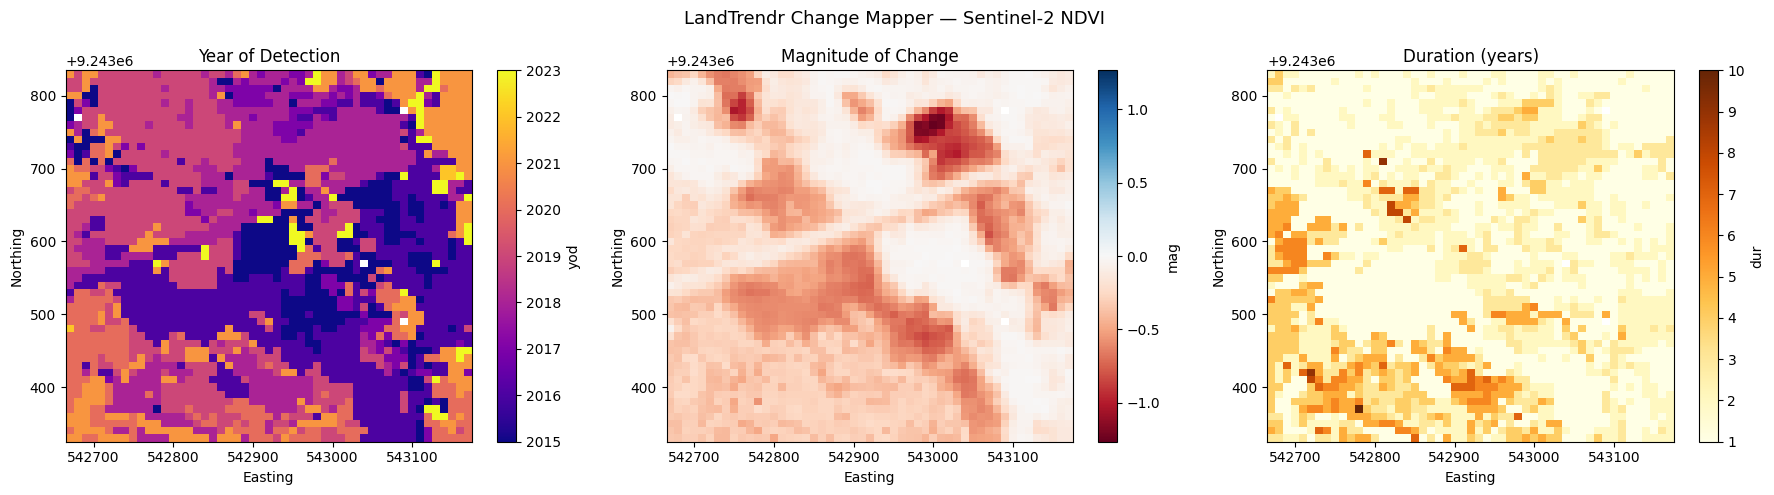

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

change["yod"].plot(ax=axes[0], cmap="plasma",    add_colorbar=True)
axes[0].set_title("Year of Detection")

change["mag"].plot(ax=axes[1], cmap="RdBu",      center=0, add_colorbar=True)
axes[1].set_title("Magnitude of Change")

change["dur"].plot(ax=axes[2], cmap="YlOrBr",    add_colorbar=True)
axes[2].set_title("Duration (years)")

for ax in axes:
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

plt.suptitle("LandTrendr Change Mapper — Sentinel-2 NDVI", fontsize=13)
plt.tight_layout()
plt.show()


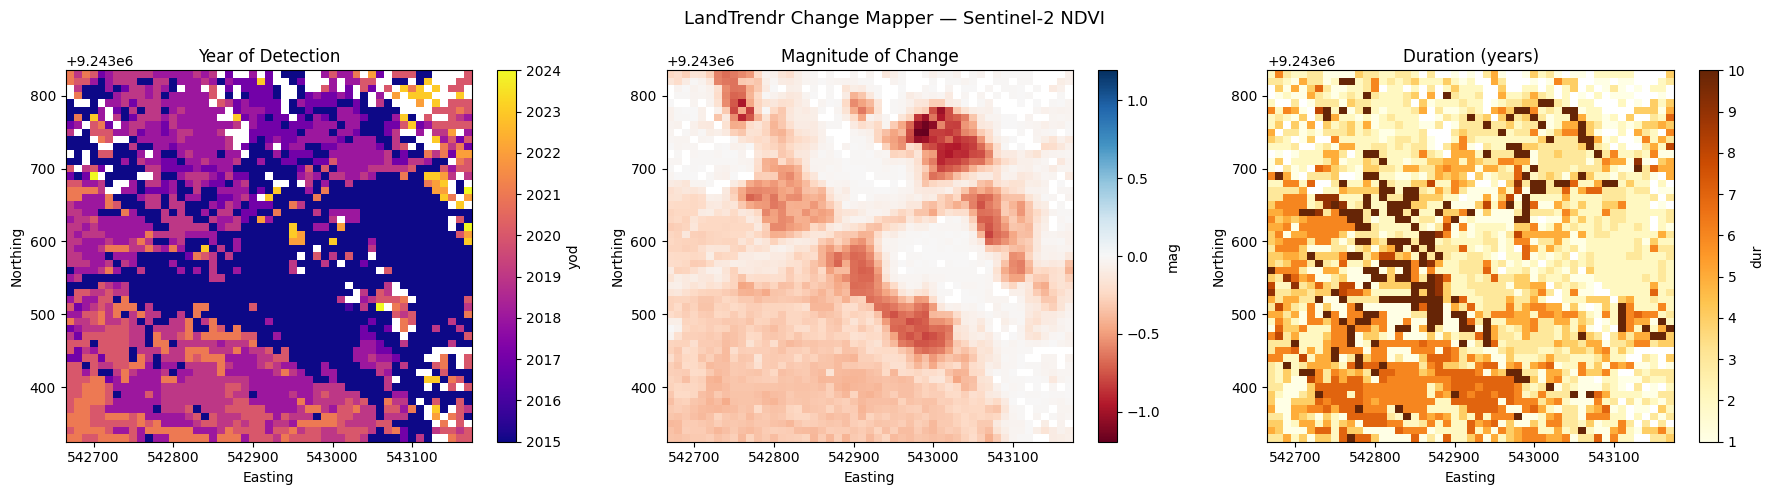

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

change["yod"].plot(ax=axes[0], cmap="plasma",    add_colorbar=True)
axes[0].set_title("Year of Detection")

change["mag"].plot(ax=axes[1], cmap="RdBu",      center=0, add_colorbar=True)
axes[1].set_title("Magnitude of Change")

change["dur"].plot(ax=axes[2], cmap="YlOrBr",    add_colorbar=True)
axes[2].set_title("Duration (years)")

for ax in axes:
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")

plt.suptitle("LandTrendr Change Mapper — Sentinel-2 NDVI", fontsize=13)
plt.tight_layout()
plt.show()


## 6. Pixel-level inspection

Pick any pixel by y/x coordinate and examine its full spectral trajectory.


In [ ]:
## 7. Direct pixel-level run (no xarray overhead)

# Extract raw numpy arrays for one pixel and call landtrendr_pixel directly.
# Useful for debugging, parameter tuning, or integration into other workflows.

from space_time_deepsearch.temporal._landtrendr_core import landtrendr_pixel

src = lt_result["source_values"].sel(y=cy, x=cx, method="nearest")

time_coord = src.time
years = time_coord.dt.year.values.astype("int32") if hasattr(time_coord.dt, "year") else time_coord.values.astype("int32")
values = src.values

fitted, is_vertex, rmse = landtrendr_pixel(years, values)

print(f"Years        : {years}")
print(f"Source NDVI  : {values.round(3)}")
print(f"Fitted NDVI  : {fitted.round(3)}")
print(f"Vertex years : {years[is_vertex]}")
print(f"RMSE         : {rmse:.4f}")


In [ ]:
# Centre pixel coordinates (UTM)
cy = float(lt_result["source_values"].y.values[len(lt_result["source_values"].y) // 2])
cx = float(lt_result["source_values"].x.values[len(lt_result["source_values"].x) // 2])

print(f"Inspecting pixel at y={cy:.0f}, x={cx:.0f}")

fig = stds.plot_pixel_trajectory(lt_result, y=cy, x=cx)
plt.show()
